# Simulating Risk of a Portfolio of Securities
We simulate different stocks and check if the simulations align with portfolio theory. In particular, we check if by diversifying a portfolio of stocks, we do indeed get the L-curve when we plot risk vs number of stocks as predicted by the theory.

We generated N stock prices via geometric Brownian motion to represent the stock market. We simulated random correlations between stock prices as well.

The portfolio is made up of $K < N$ randomly selected stocks. We then assume we have a portfolio of $K$ stocks whith equal fund allocations so each stock will have an allocation of $1/K$ of the total portfolio. We then compute the portfolio return standard deviation (risk) two ways: 

>A) Using the formula $\sigma^2_{p} = \sum p_i * p_j * \sigma_{ij}$ for stock combinations $i$ and $j$ where if $i = j$ then $\sigma_{ij} = \sigma{ii} = \sigma^2_{i}$ which is the variance of returns of stock $i$, else for $i \neq j$, $\sigma_{ij}$ is the covariance of returns between stocks $i$ and $j$

> B) We get the expected portfolio return (average of the individual returns of the K stocks) and compute the standard deviation and variance

We then plot the corresponding portfolio risk $\sigma_p$ vs $K$ and check if we will see the:
* L-curve where risk, $\sigma_p$ goes down as $K$ goes up, which is fundamental in portfolio theory (shift from unique/specific risk to market/systematic risk)
* Whether the theoretical computation A) will match the empirical computation B) of $\sigma_p$

Spoiler: Yes we see the L-curve and yes we A) exactly matches B). The math of portfolio theory checks out, supporting the idea how diversification reduces overall risk!

## We define the functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def generate_stocks(n_stocks=5, 
                    period=365 * 10, # say X years, 1 hour granularity
                    plot=False,
                    seed=42):

    # random walks for stock simulation
    np.random.seed(seed)

    price_matrix = np.zeros(shape=(n_stocks, period))
    z_matrix = np.zeros(shape=(n_stocks, period))
    stds = np.random.uniform(0.01, 0.05, size=n_stocks) # daily
    mus = stds/10000 # make returns proportional to std

    if plot:
        plt.figure(figsize=(7, 5))
    i = 0

    # First stock
    while True:
        P0 = 1 #
        delta_t = 1 # 1 day

        # brownian motion
        z1 = np.random.normal(0, 1, size=period)
        mu, std = mus[i], stds[i]
        returns = np.exp((mu - (std ** 2) / 2) * delta_t + std * np.sqrt(delta_t) * z1)
        prices = P0 * np.cumprod(returns)

        # make sure gain
        if prices[-1] > prices[0]:
            price_matrix[i, :] = prices       
            z_matrix[i, :] = z1         
            plt.plot(prices, linewidth=1, alpha=0.75)
            i += 1
            break

    # rest of the stocks
    while True:
        # generate correlated stock
        corr_coeff = np.random.uniform(-0.8, 0.8)

        # find a random stock from the existing list
        i2 = np.random.choice(range(0, i))
        mu, std = mus[i2], stds[i2]    
        z1 = z_matrix[i2, :]
        z2 = np.random.normal(0, 1, size=period) # random noise for this stock    

        zb = corr_coeff * z1 + np.sqrt(1 - corr_coeff ** 2) * z2
        returns = np.exp((mu - (std ** 2) / 2) * delta_t + std * np.sqrt(delta_t) * zb)
        prices = P0 * np.cumprod(returns)

        # make sure gain
        if prices[-1] > prices[0]:
            price_matrix[i, :] = prices        
            plt.plot(prices, linewidth=1, alpha=0.75)
            i += 1

        if i >= n_stocks:
            break

    if plot:
        plt.legend()
        plt.xlabel("time")
        plt.ylabel("price")
        plt.title("Simulated stock prices in the stock market")
        plt.tight_layout()
        plt.show()

    return price_matrix

In [8]:
# Get only K random stocks from the universe of stocks
def compute_portfolio_risk(price_matrix, portfolio_size, plot=False, seed=42):
    np.random.seed(seed)
    inds = np.random.choice(range(price_matrix.shape[0]), size=portfolio_size, replace=False)
    price_mtx_trunc = price_matrix[inds, :]
    return_mtx = (price_mtx_trunc[:, 1:] - price_mtx_trunc[:, :-1]) / price_mtx_trunc[:, :-1]

    # histograms
    if plot:
        fig, axs = plt.subplots(int(np.sqrt(portfolio_size)), int(np.sqrt(portfolio_size)), figsize=(10, 6), sharex=True)
        axs = axs.flatten()        
        for i, ax in zip(range(portfolio_size), axs):
            ax.set_title(f"Stock {i}")
            ax.hist(return_mtx[i, :], bins=20)
        plt.suptitle("Distribution of daily returns per stock")
        plt.tight_layout()
        plt.show()  

    # compute daily stdev
    stdevs = np.std(return_mtx, axis=1)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.bar([str(i) for i in range(portfolio_size)], stdevs)
        plt.xlabel("stock")
        plt.ylabel("daily return standard dev")
        plt.suptitle("Standard deviation (risk) per stock")
        plt.tight_layout()   
        plt.show()     

    # build the covariance matrix (daily returns)
    cov_mtx = np.cov(return_mtx)

    if plot:
        sns.heatmap(cov_mtx, cmap='viridis')
        plt.title("Covariance matrix")
        plt.tight_layout()
        plt.show()

    # get market portfolio variance, as computed by the theory
    # Assume same proportion of allocation per stock
    portfolio_var_theory = np.sum(cov_mtx * (1/portfolio_size)**2)
    portfolio_std_theory = np.sqrt(portfolio_var_theory)

    # compute the actual variance from the data
    return_w_prop = return_mtx * 1/portfolio_size # allocation of returns
    return_w_prop = return_w_prop.sum(axis=0) # sum returns across all stocks (returns can be summed up)
    portfolio_std_actual = np.std(return_w_prop) # compute stdev of returns
    portfolio_var_actual = portfolio_std_actual**2    

    if plot:
        # plot the performance of the portfolio
        plt.plot(np.cumprod(1+return_w_prop))
        plt.xlabel("Time")
        plt.ylabel("Cumulative return")
        plt.title("Actual portfolio cumulative return")
        plt.tight_layout()
        plt.show()

    if plot:
        print(f"portfolio_var_theory {portfolio_var_theory:.6f}")
        print(f"portfolio_var_actual {portfolio_var_actual:.6f}")
        print()
        print(f"portfolio_std_theory {portfolio_std_theory:.6f}")        
        print(f"portfolio_std_actual {portfolio_std_actual:.6f}")        

    return portfolio_std_theory, portfolio_std_actual

## We randomly generate N stocks representing the entire stock market

/var/folders/r0/vzjvg_0x34l0y0xm0pz7bd100000gn/T/ipykernel_64180/423271303.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


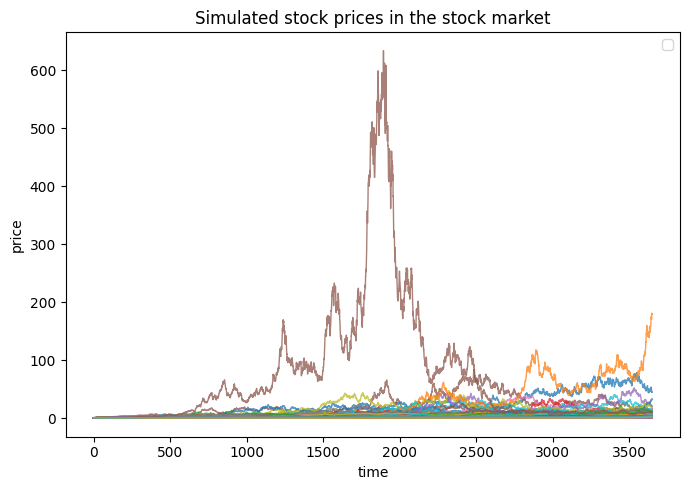

In [9]:
# generate a universe of stocks
n_stocks = 500
price_matrix = generate_stocks(n_stocks=n_stocks, period=365 * 10, plot=True, seed=42)

## We visualize the risks and returns of a portfolio of 9 random stocks

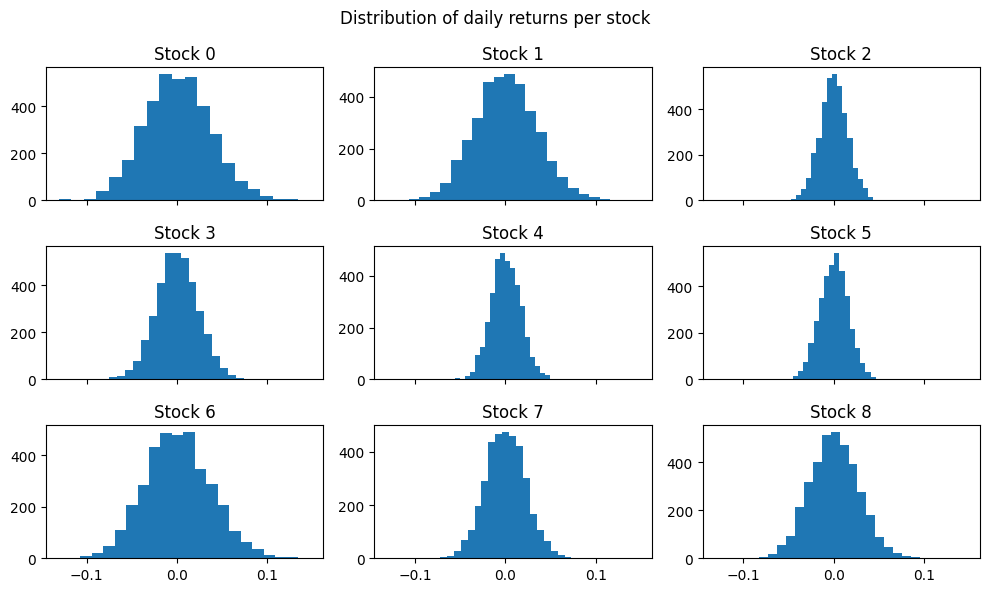

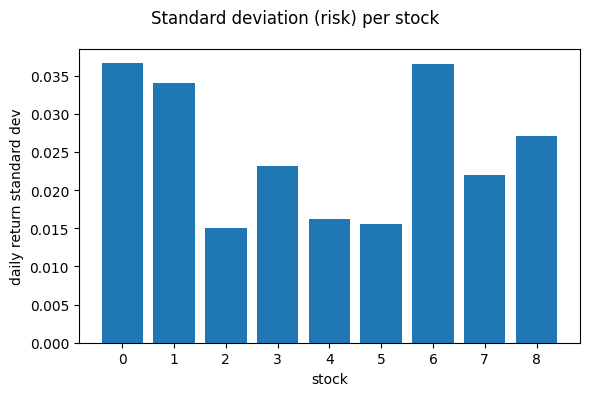

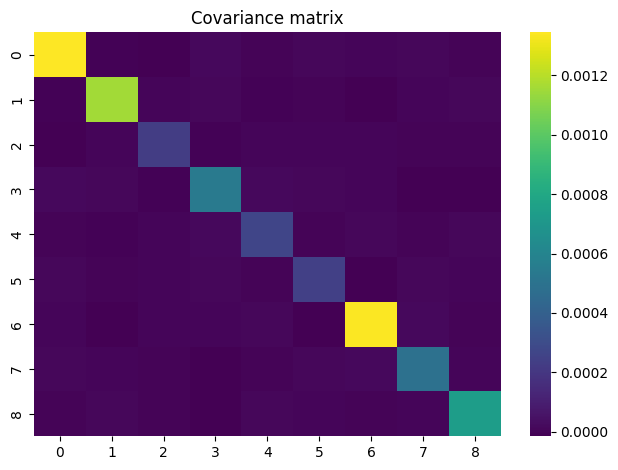

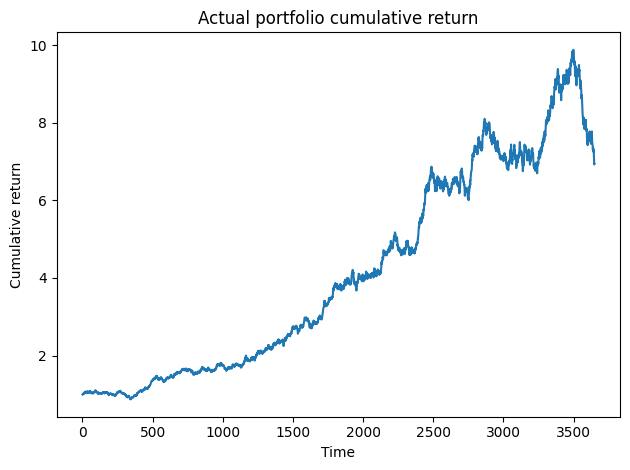

portfolio_var_theory 0.000079
portfolio_var_actual 0.000079

portfolio_std_theory 0.008890
portfolio_std_actual 0.008889


In [10]:
portfolio_var = compute_portfolio_risk(price_matrix, portfolio_size=9, plot=True, seed=42)      

## We visualize portfolio risk vs portfolio size

* We find that diversification reduces the risk of the portfolio to approach the risk of the entire market
* The theoretical computation using stock return covariances matches exactly the direct computation of first getting the total return of the portfolio and getting its standard deviation

In [11]:
# Plot the portfolio std vs count stocks
portfolio_sizes = range(10, 500)
portfolio_stds_theory = []
portfolio_stds_actual = []
for portfolio_size in portfolio_sizes:
    portfolio_std_theory, portfolio_std_actual = compute_portfolio_risk(price_matrix, portfolio_size=portfolio_size, plot=False, seed=None)
    portfolio_stds_theory.append(portfolio_std_theory)
    portfolio_stds_actual.append(portfolio_std_actual)

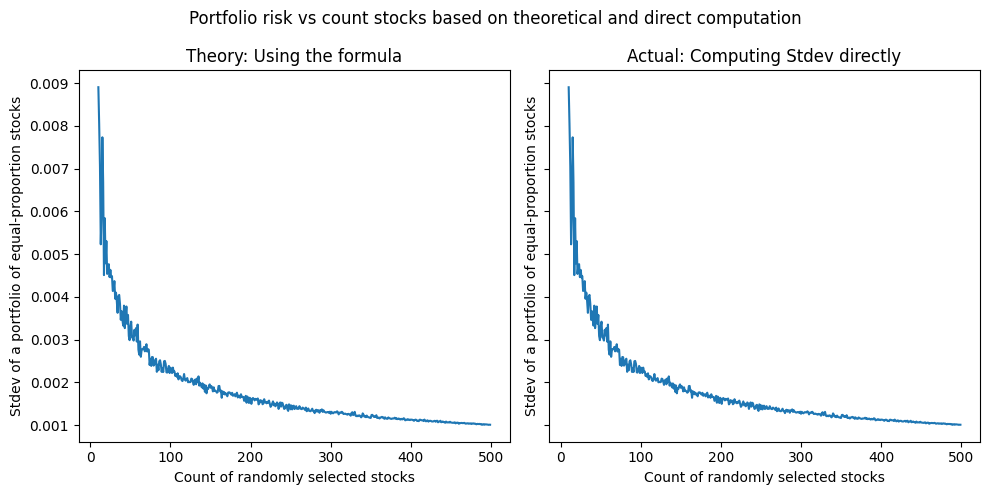

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axs[0].plot(portfolio_sizes, portfolio_stds_theory)
axs[0].set_ylabel("Stdev of a portfolio of equal-proportion stocks")
axs[0].set_xlabel("Count of randomly selected stocks")
axs[0].set_title("Theory: Using the formula")

axs[1].plot(portfolio_sizes, portfolio_stds_actual)
axs[1].set_ylabel("Stdev of a portfolio of equal-proportion stocks")
axs[1].set_xlabel("Count of randomly selected stocks")
axs[1].set_title("Actual: Computing Stdev directly")
plt.suptitle("Portfolio risk vs count stocks based on theoretical and direct computation")
plt.tight_layout()